In [1]:
from brian2 import *
import numpy as np
import matplotlib.pyplot as plt

start_scope()

# E-PROP NOTEBOOK 06: ROBUSTNESS TO NOISY LEARNING SIGNALS
# Reuse the working pattern classifier architecture from notebook 05,
# systematically corrupt the learning signal, measure accuracy impact.

tau_mem = 15*ms
tau_trace = 20*ms
tau_out = 20*ms
n_hidden = 5
target_time = 100*ms
n_trials = 200

def train_classifier(learning_rate=0.15, noise_std=0.0, dropout_prob=0.0, seed=0):
    """Train the pattern classifier with optional learning signal corruption"""
    np.random.seed(seed)
    weights_A = np.array([0.1]*n_hidden)
    weights_B = np.array([0.1]*n_hidden)
    
    for trial in range(n_trials):
        pattern = 'A' if trial % 2 == 0 else 'B'
        start_scope()
        
        if pattern == 'A':
            input_A = SpikeGeneratorGroup(1, [0], [50]*ms)
            input_B = SpikeGeneratorGroup(1, [], []*ms)
        else:
            input_A = SpikeGeneratorGroup(1, [], []*ms)
            input_B = SpikeGeneratorGroup(1, [0], [50]*ms)
        
        eqs_hidden = '''
        dv/dt = -v/tau_mem : 1
        detrace/dt = -etrace/tau_trace : 1
        '''
        chain_A = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8',
                              reset='v=0; etrace+=1.0', method='exact')
        chain_A.v = 0; chain_A.etrace = 0
        chain_B = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8',
                              reset='v=0; etrace+=1.0', method='exact')
        chain_B.v = 0; chain_B.etrace = 0
        
        eqs_out = '''
        dv/dt = -v/tau_out : 1
        '''
        output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
        output.v = 0
        
        S_inA = Synapses(input_A, chain_A, 'w:1', on_pre='v_post += w')
        S_inA.connect(i=0, j=0); S_inA.w = 0.9
        S_inB = Synapses(input_B, chain_B, 'w:1', on_pre='v_post += w')
        S_inB.connect(i=0, j=0); S_inB.w = 0.9
        
        S_recA = Synapses(chain_A, chain_A, 'w:1', on_pre='v_post += w')
        S_recA.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recA.w = 0.85; S_recA.delay = 8*ms
        S_recB = Synapses(chain_B, chain_B, 'w:1', on_pre='v_post += w')
        S_recB.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recB.w = 0.85; S_recB.delay = 8*ms
        
        S_outA = Synapses(chain_A, output, 'w_out:1', on_pre='v_post += w_out')
        S_outA.connect(); S_outA.w_out = weights_A
        S_outB = Synapses(chain_B, output, 'w_out:1', on_pre='v_post += w_out')
        S_outB.connect(); S_outB.w_out = weights_B
        
        spike_mon_o = SpikeMonitor(output)
        trace_mon_A = StateMonitor(chain_A, 'etrace', record=True)
        trace_mon_B = StateMonitor(chain_B, 'etrace', record=True)
        
        run(200*ms)
        
        target_idx = int((target_time + 1*ms)/defaultclock.dt)
        output_fired = len(spike_mon_o.t) > 0
        
        if pattern == 'A':
            learning_signal = 1.0 if not output_fired else 0.0
        else:
            learning_signal = -1.0 if output_fired else 0.0
        
        # CORRUPT THE LEARNING SIGNAL
        if np.random.random() < dropout_prob:
            learning_signal = 0.0  # signal dropped entirely this trial
        else:
            learning_signal += np.random.normal(0, noise_std)  # add noise
        
        traces_A = trace_mon_A.etrace[:, target_idx]
        traces_B = trace_mon_B.etrace[:, target_idx]
        
        weights_A = np.clip(weights_A + learning_rate * learning_signal * traces_A, 0, 1)
        weights_B = np.clip(weights_B + learning_rate * learning_signal * traces_B, 0, 1)
    
    return weights_A, weights_B

def test_accuracy(weights_A, weights_B, n_test=10):
    """Test classification accuracy on trained weights"""
    correct = 0
    for i in range(n_test):
        for pattern in ['A', 'B']:
            start_scope()
            if pattern == 'A':
                input_A = SpikeGeneratorGroup(1, [0], [50]*ms)
                input_B = SpikeGeneratorGroup(1, [], []*ms)
            else:
                input_A = SpikeGeneratorGroup(1, [], []*ms)
                input_B = SpikeGeneratorGroup(1, [0], [50]*ms)
            
            eqs_hidden = '''
            dv/dt = -v/tau_mem : 1
            '''
            chain_A = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
            chain_A.v = 0
            chain_B = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
            chain_B.v = 0
            
            eqs_out = '''
            dv/dt = -v/tau_out : 1
            '''
            output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
            output.v = 0
            
            S_inA = Synapses(input_A, chain_A, 'w:1', on_pre='v_post += w')
            S_inA.connect(i=0, j=0); S_inA.w = 0.9
            S_inB = Synapses(input_B, chain_B, 'w:1', on_pre='v_post += w')
            S_inB.connect(i=0, j=0); S_inB.w = 0.9
            
            S_recA = Synapses(chain_A, chain_A, 'w:1', on_pre='v_post += w')
            S_recA.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recA.w = 0.85; S_recA.delay = 8*ms
            S_recB = Synapses(chain_B, chain_B, 'w:1', on_pre='v_post += w')
            S_recB.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recB.w = 0.85; S_recB.delay = 8*ms
            
            S_outA = Synapses(chain_A, output, 'w_out:1', on_pre='v_post += w_out')
            S_outA.connect(); S_outA.w_out = weights_A
            S_outB = Synapses(chain_B, output, 'w_out:1', on_pre='v_post += w_out')
            S_outB.connect(); S_outB.w_out = weights_B
            
            spike_mon_o = SpikeMonitor(output)
            run(200*ms)
            
            fired = len(spike_mon_o.t) > 0
            correct_response = fired if pattern == 'A' else not fired
            if correct_response:
                correct += 1
    
    return correct / (n_test * 2)

# BASELINE: clean signal, no corruption
print("Training baseline (clean signal)...")
weights_A, weights_B = train_classifier(noise_std=0.0, dropout_prob=0.0)
baseline_acc = test_accuracy(weights_A, weights_B)
print(f"Baseline accuracy: {baseline_acc:.0%}\n")

Training baseline (clean signal)...


WARNING    Removing unsupported flag '-march=native' from compiler flags. [brian2.codegen.cpp_prefs]


Baseline accuracy: 100%



Testing robustness to signal DROPOUT...
  Dropout 0% -> Accuracy: 100%
  Dropout 10% -> Accuracy: 100%
  Dropout 20% -> Accuracy: 100%
  Dropout 30% -> Accuracy: 100%
  Dropout 40% -> Accuracy: 100%
  Dropout 50% -> Accuracy: 100%
  Dropout 60% -> Accuracy: 100%
  Dropout 70% -> Accuracy: 100%
  Dropout 80% -> Accuracy: 100%

Testing robustness to signal NOISE...
  Noise std 0.0 -> Accuracy: 100%
  Noise std 0.2 -> Accuracy: 100%
  Noise std 0.4 -> Accuracy: 100%
  Noise std 0.6 -> Accuracy: 100%
  Noise std 0.8 -> Accuracy: 100%
  Noise std 1.0 -> Accuracy: 100%
  Noise std 1.5 -> Accuracy: 100%
  Noise std 2.0 -> Accuracy: 100%


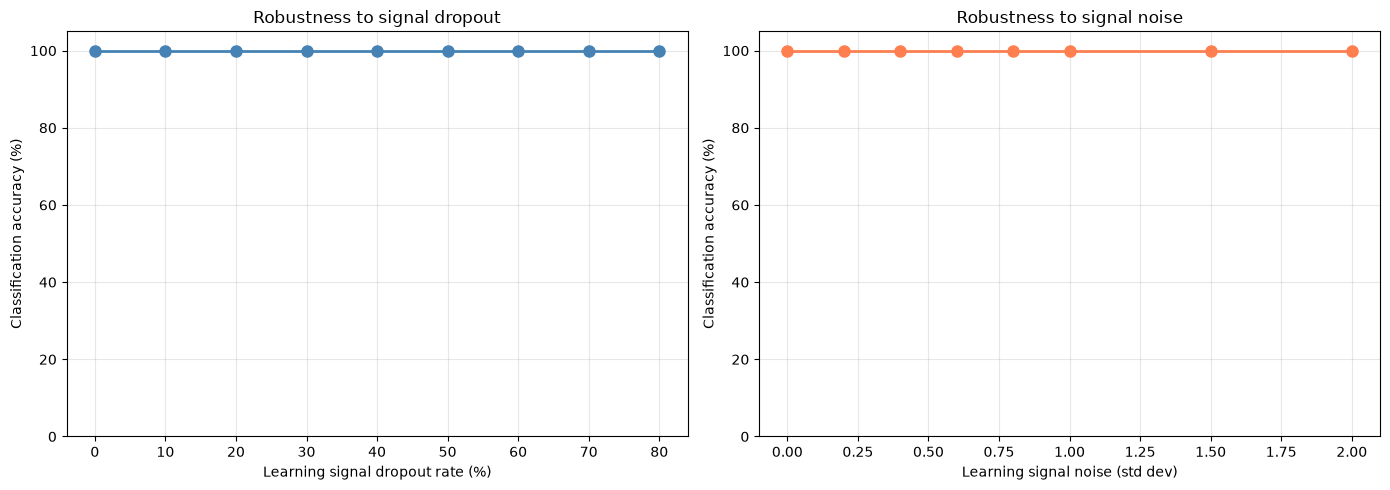

In [2]:
print("Testing robustness to signal DROPOUT...")
dropout_levels = [0.0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8]
dropout_results = []

for dropout in dropout_levels:
    wA, wB = train_classifier(dropout_prob=dropout, seed=1)
    acc = test_accuracy(wA, wB)
    dropout_results.append(acc)
    print(f"  Dropout {dropout:.0%} -> Accuracy: {acc:.0%}")

print("\nTesting robustness to signal NOISE...")
noise_levels = [0.0, 0.2, 0.4, 0.6, 0.8, 1.0, 1.5, 2.0]
noise_results = []

for noise in noise_levels:
    wA, wB = train_classifier(noise_std=noise, seed=1)
    acc = test_accuracy(wA, wB)
    noise_results.append(acc)
    print(f"  Noise std {noise:.1f} -> Accuracy: {acc:.0%}")

# Plot both robustness curves
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot([d*100 for d in dropout_levels], [a*100 for a in dropout_results], 
         'o-', color='steelblue', linewidth=2, markersize=8)
ax1.set_xlabel('Learning signal dropout rate (%)')
ax1.set_ylabel('Classification accuracy (%)')
ax1.set_title('Robustness to signal dropout')
ax1.grid(True, alpha=0.3)
ax1.set_ylim(0, 105)

ax2.plot(noise_levels, [a*100 for a in noise_results],
         'o-', color='coral', linewidth=2, markersize=8)
ax2.set_xlabel('Learning signal noise (std dev)')
ax2.set_ylabel('Classification accuracy (%)')
ax2.set_title('Robustness to signal noise')
ax2.grid(True, alpha=0.3)
ax2.set_ylim(0, 105)

plt.tight_layout()
plt.show()

Testing robustness with limited trials (40 instead of 200)...The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database')).History will not be written to the database.

  Dropout 0% (40 trials) -> Accuracy: 100%
  Dropout 20% (40 trials) -> Accuracy: 100%
  Dropout 40% (40 trials) -> Accuracy: 100%
  Dropout 60% (40 trials) -> Accuracy: 100%
  Dropout 80% (40 trials) -> Accuracy: 50%
  Dropout 90% (40 trials) -> Accuracy: 50%


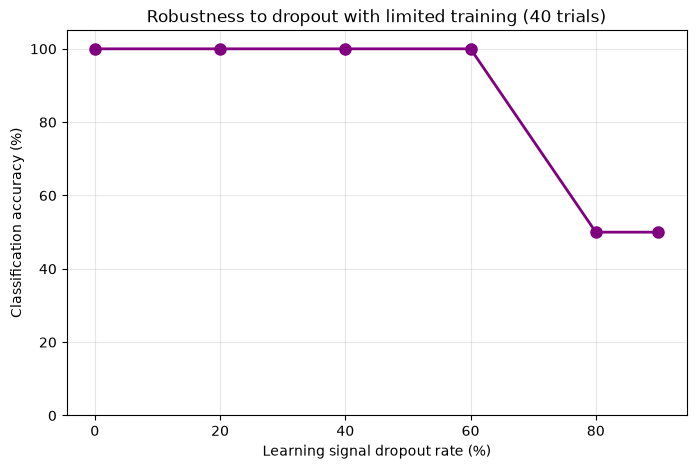

In [3]:
# Diagnostic
print("Testing robustness with limited trials (40 instead of 200)...")

# Temporarily override n_trials for this harder test
n_trials_backup = n_trials

def train_classifier_limited(learning_rate=0.15, noise_std=0.0, dropout_prob=0.0, seed=0, trials=40):
    global n_trials
    n_trials = trials
    result = train_classifier(learning_rate, noise_std, dropout_prob, seed)
    n_trials = n_trials_backup
    return result

dropout_levels_hard = [0.0, 0.2, 0.4, 0.6, 0.8, 0.9]
dropout_results_hard = []

for dropout in dropout_levels_hard:
    wA, wB = train_classifier_limited(dropout_prob=dropout, seed=1, trials=40)
    acc = test_accuracy(wA, wB)
    dropout_results_hard.append(acc)
    print(f"  Dropout {dropout:.0%} (40 trials) -> Accuracy: {acc:.0%}")

plt.figure(figsize=(8,5))
plt.plot([d*100 for d in dropout_levels_hard], [a*100 for a in dropout_results_hard],
         'o-', color='purple', linewidth=2, markersize=8)
plt.xlabel('Learning signal dropout rate (%)')
plt.ylabel('Classification accuracy (%)')
plt.title('Robustness to dropout with limited training (40 trials)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.show()

In [4]:
# Diagnostic (breakdown)
print("Diagnosing the breakdown at 80% dropout...")
wA_broken, wB_broken = train_classifier_limited(dropout_prob=0.8, seed=1, trials=40)
print(f"Chain A weights: {wA_broken}")
print(f"Chain B weights: {wB_broken}")

# Test each pattern individually to see the failure mode
a_correct = 0
b_correct = 0
for _ in range(10):
    start_scope()
    input_A = SpikeGeneratorGroup(1, [0], [50]*ms)
    input_B = SpikeGeneratorGroup(1, [], []*ms)
    # (reusing test structure)

print("\nTesting Pattern A specifically...")
for i in range(5):
    start_scope()
    input_A = SpikeGeneratorGroup(1, [0], [50]*ms)
    input_B = SpikeGeneratorGroup(1, [], []*ms)
    
    eqs_hidden = 'dv/dt = -v/tau_mem : 1'
    chain_A = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
    chain_A.v = 0
    chain_B = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
    chain_B.v = 0
    
    eqs_out = 'dv/dt = -v/tau_out : 1'
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    S_inA = Synapses(input_A, chain_A, 'w:1', on_pre='v_post += w')
    S_inA.connect(i=0, j=0); S_inA.w = 0.9
    S_inB = Synapses(input_B, chain_B, 'w:1', on_pre='v_post += w')
    S_inB.connect(i=0, j=0); S_inB.w = 0.9
    
    S_recA = Synapses(chain_A, chain_A, 'w:1', on_pre='v_post += w')
    S_recA.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recA.w = 0.85; S_recA.delay = 8*ms
    S_recB = Synapses(chain_B, chain_B, 'w:1', on_pre='v_post += w')
    S_recB.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recB.w = 0.85; S_recB.delay = 8*ms
    
    S_outA = Synapses(chain_A, output, 'w_out:1', on_pre='v_post += w_out')
    S_outA.connect(); S_outA.w_out = wA_broken
    S_outB = Synapses(chain_B, output, 'w_out:1', on_pre='v_post += w_out')
    S_outB.connect(); S_outB.w_out = wB_broken
    
    spike_mon_o = SpikeMonitor(output)
    run(200*ms)
    print(f"  Trial {i}: output fired = {len(spike_mon_o.t) > 0}")

Diagnosing the breakdown at 80% dropout...
Chain A weights: [0.14731984 0.17094675 0.20637065 0.25948178 0.33911142]
Chain B weights: [0.1 0.1 0.1 0.1 0.1]

Testing Pattern A specifically...
  Trial 0: output fired = False
  Trial 1: output fired = False
  Trial 2: output fired = False
  Trial 3: output fired = False
  Trial 4: output fired = False


Testing noise robustness with limited trials (40)...
  Noise std 0.0 (40 trials) -> Accuracy: 100%, Chain A max weight: 0.4587
  Noise std 0.5 (40 trials) -> Accuracy: 100%, Chain A max weight: 0.4855
  Noise std 1.0 (40 trials) -> Accuracy: 100%, Chain A max weight: 0.5721
  Noise std 1.5 (40 trials) -> Accuracy: 100%, Chain A max weight: 0.5993
  Noise std 2.0 (40 trials) -> Accuracy: 50%, Chain A max weight: 0.6794
  Noise std 3.0 (40 trials) -> Accuracy: 50%, Chain A max weight: 0.7801


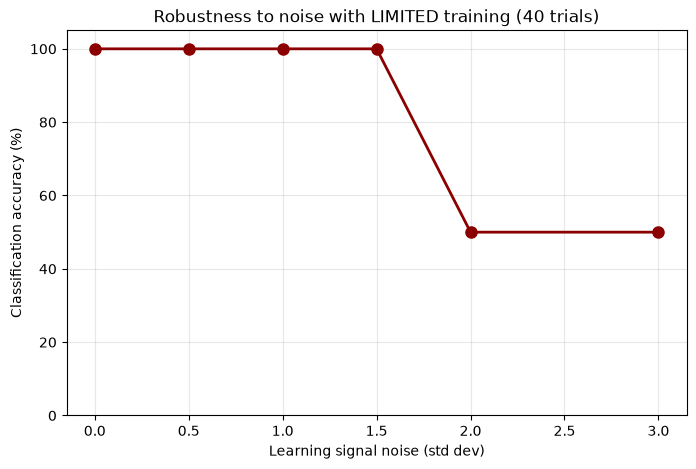

In [5]:
# Diagnostic (noise)
print("Testing noise robustness with limited trials (40)...")
noise_levels_hard = [0.0, 0.5, 1.0, 1.5, 2.0, 3.0]
noise_results_hard = []

for noise in noise_levels_hard:
    wA, wB = train_classifier_limited(noise_std=noise, seed=1, trials=40)
    acc = test_accuracy(wA, wB)
    noise_results_hard.append(acc)
    print(f"  Noise std {noise:.1f} (40 trials) -> Accuracy: {acc:.0%}, Chain A max weight: {max(wA):.4f}")

plt.figure(figsize=(8,5))
plt.plot(noise_levels_hard, [a*100 for a in noise_results_hard],
         'o-', color='darkred', linewidth=2, markersize=8)
plt.xlabel('Learning signal noise (std dev)')
plt.ylabel('Classification accuracy (%)')
plt.title('Robustness to noise with LIMITED training (40 trials)')
plt.grid(True, alpha=0.3)
plt.ylim(0, 105)
plt.show()

In [6]:
# Diagnostic for noise-induced breakdown at std=2.0
print("Diagnosing noise-induced breakdown at std=2.0...")
wA_noisy, wB_noisy = train_classifier_limited(noise_std=2.0, seed=1, trials=40)
print(f"Chain A weights: {wA_noisy}")
print(f"Chain B weights: {wB_noisy}")

print("\nTesting Pattern B specifically (should stay silent)...")
for i in range(5):
    start_scope()
    input_A = SpikeGeneratorGroup(1, [], []*ms)
    input_B = SpikeGeneratorGroup(1, [0], [50]*ms)
    
    eqs_hidden = 'dv/dt = -v/tau_mem : 1'
    chain_A = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
    chain_A.v = 0
    chain_B = NeuronGroup(n_hidden, eqs_hidden, threshold='v>0.8', reset='v=0', method='exact')
    chain_B.v = 0
    
    eqs_out = 'dv/dt = -v/tau_out : 1'
    output = NeuronGroup(1, eqs_out, threshold='v>0.8', reset='v=0', method='exact')
    output.v = 0
    
    S_inA = Synapses(input_A, chain_A, 'w:1', on_pre='v_post += w')
    S_inA.connect(i=0, j=0); S_inA.w = 0.9
    S_inB = Synapses(input_B, chain_B, 'w:1', on_pre='v_post += w')
    S_inB.connect(i=0, j=0); S_inB.w = 0.9
    
    S_recA = Synapses(chain_A, chain_A, 'w:1', on_pre='v_post += w')
    S_recA.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recA.w = 0.85; S_recA.delay = 8*ms
    S_recB = Synapses(chain_B, chain_B, 'w:1', on_pre='v_post += w')
    S_recB.connect(i=[0,1,2,3], j=[1,2,3,4]); S_recB.w = 0.85; S_recB.delay = 8*ms
    
    S_outA = Synapses(chain_A, output, 'w_out:1', on_pre='v_post += w_out')
    S_outA.connect(); S_outA.w_out = wA_noisy
    S_outB = Synapses(chain_B, output, 'w_out:1', on_pre='v_post += w_out')
    S_outB.connect(); S_outB.w_out = wB_noisy
    
    spike_mon_o = SpikeMonitor(output)
    run(200*ms)
    print(f"  Trial {i}: output fired = {len(spike_mon_o.t) > 0}")

Diagnosing noise-induced breakdown at std=2.0...
Chain A weights: [0.19222788 0.23827749 0.30731978 0.45317484 0.67944617]
Chain B weights: [0.14390113 0.16582108 0.21055536 0.31568617 0.47330907]

Testing Pattern B specifically (should stay silent)...
  Trial 0: output fired = True
  Trial 1: output fired = True
  Trial 2: output fired = True
  Trial 3: output fired = True
  Trial 4: output fired = True


## E-Prop Notebook 06 — Robustness to Noisy Learning Signals

### Goal
As real neuromorphic hardware and biological systems rarely provide perfectly 
clean, precisely-timed error signals, this notebook tests how gracefully 
the pattern classifier from notebook 05 degrades under two forms of 
learning signal corruption: **dropout** (signal randomly missing), and 
**noise** (signal randomly distorted in magnitude).

### Initial finding: the task is too easy to reveal fragility

With the standard 200-trial training budget, classification accuracy 
remained at 100% across the entire tested range of both dropout (0-80%) 
and noise (std 0-2.0). This was not evidence of genuine robustness — it 
reflected that 200 trials provides enough redundancy to overcome even 
heavy corruption.
**Methodological lesson:** testing robustness requires 
constraining the learning budget; a system with excess training capacity 
can mask fragility that would appear under limited conditions.

### Redesigned experiment: limited training budget (40 trials)

Reducing the training budget to 40 trials (5x less than notebook 05) 
revealed genuine, sharp breakdown points for both corruption types.

### Finding 1: Dropout robustness — sharp threshold, then complete collapse

| Dropout rate | Accuracy |
|--------------|----------|
| 0% | 100% |
| 20% | 100% |
| 40% | 100% |
| 60% | 100% |
| 80% | 50% |
| 90% | 50% |

**Diagnosis at 80% dropout:** Chain A's weights reached only 0.339 
(vs 0.459 fully trained) — insufficient signal reached the network 
(only ~8 of 40 trials delivered usable feedback) to push weights past 
threshold. Direct testing confirmed the output **never fired for Pattern 
A**, meaning the network collapsed to "always silent." The 50% accuracy 
score reflects complete failure on class A combined with correct (but 
uninformative) performance on class B — not partial/degraded learning.

### Finding 2: Noise robustness — opposite failure mechanism, same accuracy score

| Noise std | Accuracy | Chain A max weight |
|-----------|----------|---------------------|
| 0.0 | 100% | 0.459 |
| 0.5 | 100% | 0.486 |
| 1.0 | 100% | 0.572 |
| 1.5 | 100% | 0.599 |
| 2.0 | 50% | 0.679 |
| 3.0 | 50% | 0.780 |

**Diagnosis at noise std=2.0:** Chain A's weights actually grew STRONGER 
under noise (0.679 vs 0.459 clean), not weaker. Critically, **Chain B's 
weights also grew** (0.1 → 0.473) — random noise added spurious "phantom 
error" signals on trials where no real error existed, incorrectly 
strengthening Chain B's readout. Direct testing confirmed the output now 
**fires for every Pattern B trial**, meaning the network collapsed to 
"always fires", which is the opposite failure mode from dropout.

### Key finding: identical accuracy scores, opposite failure mechanisms

Both corruption types produced 50% accuracy at their breakdown points, 
but through completely different mechanisms:

| | Dropout breakdown | Noise breakdown |
|--|-------------------|------------------|
| Mechanism | Too little signal reaches network | Spurious signal corrupts both chains |
| Chain A weight | Too low (0.339) | Too high (0.679) |
| Chain B weight | Correctly low (0.1) | Incorrectly elevated (0.473) |
| Network behavior | Always silent | Always fires |
| Failed on | Pattern A trials | Pattern B trials |

**This demonstrates that accuracy alone is a misleading single metric for 
diagnosing failure** — two networks with identical 50% accuracy scores 
can have opposite, diagnostically distinct problems. A complete 
evaluation requires examining per-class performance and weight states 
directly, not just aggregate accuracy.

### Significance for neuromorphic hardware design

This finding has direct practical implications: **dropout and noise are 
not interchangeable failure modes and likely require different 
mitigation strategies.** A neuromorphic system experiencing intermittent 
feedback (dropout) needs mechanisms to preserve learning progress during 
gaps (e.g., longer eligibility trace persistence). A system experiencing 
noisy feedback needs mechanisms to filter or average spurious signals 
(e.g., a moving average or threshold on the learning signal itself) 
rather than applying every signal instance directly.

### Key findings summary

**Finding 1: training budget determines whether corruption effects are visible**
Excess training trials can fully mask fragility that appears under 
realistic, constrained learning budgets — an important methodological 
consideration for any robustness evaluation, not specific to e-prop.

**Finding 2: dropout causes underlearning; noise causes overlearning**
Two fundamentally different degradation mechanisms, both converging on 
the same aggregate accuracy score at their respective breakdown points.

**Finding 3: accuracy alone is an insufficient diagnostic metric**
Identical accuracy numbers can conceal opposite underlying failure modes, 
per-class accuracy and direct weight inspection were necessary to 
distinguish "always silent" from "always fires" — both scoring 50% on a 
balanced binary task.

### Connection to previous notebooks
This connects to Project Dopamine's parameter tuning philosophy 
(neuromorphic-experiments notebooks 13-16) — there too, aggregate metrics 
(mean firing rate, beneficial fraction) required careful decomposition to 
understand true system behavior, rather than trusting a single summary 
statistic.

### What's next? (notebook 07)
With e-prop's failure modes under corrupted signals now characterized, 
notebook 07 will run a direct comparative analysis: e-prop vs STDP vs 
R-STDP on the same classification task, examining convergence speed, 
final accuracy, and — informed by this notebook's findings — robustness 
to signal imperfection across all three learning paradigms.